
# DL Assignment 03

**Name:** Fahim Montasir

**Course Email:** fahimmontasirshakil@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


In [2]:
# Answer 01: Dataset preparation and preprocessing (manual pipeline, no Dataset/DataLoader)

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1) Load dataset
df = pd.read_csv("cost-of-living_v2.csv")
print("Original shape:", df.shape)

# 2) Feature/target selection
# Decision: Use numeric x1..x55 columns as input features.
# city/country are high-cardinality text columns; we drop them for a compact neural baseline.
feature_cols = [c for c in df.columns if c.startswith("x")]
target_col = "data_quality"  # Binary label (0/1)

# 3) Handle missing values and types
# Convert all selected columns to numeric (invalid text -> NaN), then impute numeric NaNs by median.
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Keep rows with available target
data = df.dropna(subset=[target_col]).copy()

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(data[feature_cols])
y = data[target_col].astype(int).to_numpy()

# 4) Feature scaling
# Decision: StandardScaler helps neural nets converge faster by keeping features on similar scales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 5) Train/test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 6) Convert to NumPy arrays (already NumPy) and PyTorch tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np.reshape(-1, 1), dtype=torch.float32)

print("Prepared data shape:", data.shape)
print("X_train_np:", X_train_np.shape, "X_test_np:", X_test_np.shape)
print("Tensor shapes ->", X_train_tensor.shape, y_train_tensor.shape)
print("Class distribution (0/1):", np.bincount(y))

Original shape: (4956, 58)
Prepared data shape: (4956, 58)
X_train_np: (3964, 55) X_test_np: (992, 55)
Tensor shapes -> torch.Size([3964, 55]) torch.Size([3964, 1])
Class distribution (0/1): [4033  923]


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [3]:
# Answer 02: Define neural network using nn.Module + justification

# Justification:
# - Hidden neurons: 32 provides enough non-linearity without over-parameterizing this small dataset.
# - Activation: ReLU is computationally efficient and reduces vanishing-gradient issues.
# - Output: Single logit for binary classification.

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # raw logit
        )

    def forward(self, x):
        return self.net(x)


model = BinaryClassifier(input_dim=X_train_tensor.shape[1], hidden_dim=32)


def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


print(model)
print("Total trainable parameters:", count_trainable_params(model))

BinaryClassifier(
  (net): Sequential(
    (0): Linear(in_features=55, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total trainable parameters: 1825


# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

In [4]:
# Answer 03: Loss function and optimizer choice

# Choice of loss:
# - BCEWithLogitsLoss is suitable for binary classification.
# - It is numerically more stable than applying sigmoid + BCELoss separately.
criterion = nn.BCEWithLogitsLoss()

# Choice of optimizer:
# - Adam adapts learning rates per-parameter and converges well on tabular datasets.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Initial learning rate:", learning_rate)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Initial learning rate: 0.01


# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

Epoch [010/150] - Loss: 0.4779
Epoch [020/150] - Loss: 0.4058
Epoch [030/150] - Loss: 0.3752
Epoch [040/150] - Loss: 0.3494
Epoch [050/150] - Loss: 0.3268
Epoch [060/150] - Loss: 0.3067
Epoch [070/150] - Loss: 0.2881
Epoch [080/150] - Loss: 0.2710
Epoch [090/150] - Loss: 0.2550
Epoch [100/150] - Loss: 0.2399
Epoch [110/150] - Loss: 0.2259
Epoch [120/150] - Loss: 0.2127
Epoch [130/150] - Loss: 0.2019
Epoch [140/150] - Loss: 0.1909
Epoch [150/150] - Loss: 0.1817


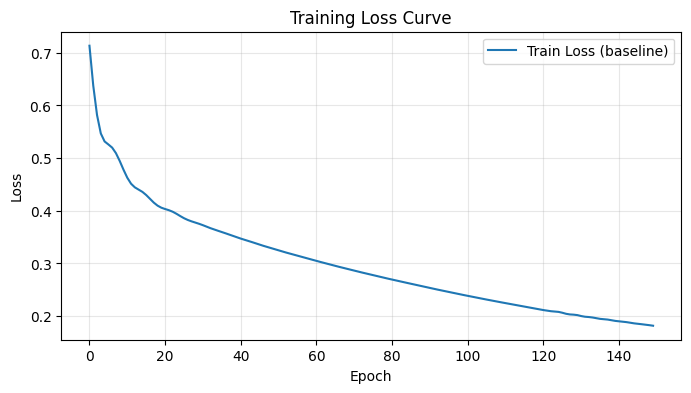

In [5]:
# Answer 04: Full training loop (forward, loss, backward, update, reset)

# What happens each epoch:
# 1) optimizer.zero_grad() -> reset old gradients (PyTorch accumulates gradients by default)
# 2) model(X_train_tensor) -> forward pass
# 3) criterion(...) -> compute loss
# 4) loss.backward() -> backpropagate gradients
# 5) optimizer.step() -> update parameters

num_epochs = 150
train_loss_history = []

for epoch in range(1, num_epochs + 1):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    train_loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch [{epoch:03d}/{num_epochs}] - Loss: {loss.item():.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="Train Loss (baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [6]:
# Answer 05: Evaluate on test data (classification -> Accuracy)

model.eval()
with torch.no_grad():
    train_logits = model(X_train_tensor)
    test_logits = model(X_test_tensor)

    train_probs = torch.sigmoid(train_logits)
    test_probs = torch.sigmoid(test_logits)

    train_preds = (train_probs >= 0.5).float()
    test_preds = (test_probs >= 0.5).float()

    train_acc = (train_preds.eq(y_train_tensor).float().mean().item())
    test_acc = (test_preds.eq(y_test_tensor).float().mean().item())

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")

acc_gap = train_acc - test_acc
if acc_gap > 0.08:
    fit_comment = "Potential overfitting (training accuracy is noticeably higher than testing accuracy)."
elif train_acc < 0.65 and test_acc < 0.65:
    fit_comment = "Potential underfitting (both training and testing accuracy are relatively low)."
else:
    fit_comment = "Reasonable fit (training and testing performance are relatively close)."

print("Train-Test Gap:", round(acc_gap, 4))
print("Model diagnosis:", fit_comment)

Training Accuracy: 0.9301
Testing Accuracy : 0.8740
Train-Test Gap: 0.0561
Model diagnosis: Reasonable fit (training and testing performance are relatively close).


# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

[v2] Epoch [010/150] - Loss: 0.6943
[v2] Epoch [020/150] - Loss: 0.6291
[v2] Epoch [030/150] - Loss: 0.5814
[v2] Epoch [040/150] - Loss: 0.5502
[v2] Epoch [050/150] - Loss: 0.5304
[v2] Epoch [060/150] - Loss: 0.5159
[v2] Epoch [070/150] - Loss: 0.5034
[v2] Epoch [080/150] - Loss: 0.4918
[v2] Epoch [090/150] - Loss: 0.4812
[v2] Epoch [100/150] - Loss: 0.4715
[v2] Epoch [110/150] - Loss: 0.4626
[v2] Epoch [120/150] - Loss: 0.4545
[v2] Epoch [130/150] - Loss: 0.4469
[v2] Epoch [140/150] - Loss: 0.4396
[v2] Epoch [150/150] - Loss: 0.4325

Comparison Summary:


,Model,Final Train Loss,Train Accuracy,Test Accuracy,Epoch to reach loss<=0.202
0,Baseline (lr=0.01),0.181711,0.930121,0.873992,131.0
1,Modified (lr=0.001),0.432532,0.823915,0.828629,NaN


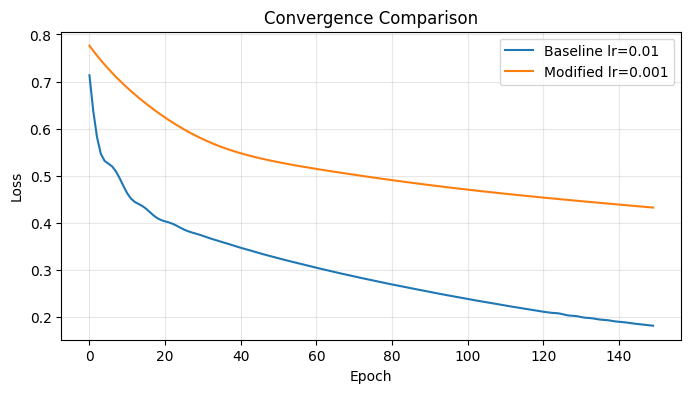

In [7]:
# Answer 06: Modify one hyperparameter and compare
# Change applied: learning rate from 0.01 -> 0.001

model_v2 = BinaryClassifier(input_dim=X_train_tensor.shape[1], hidden_dim=32)
criterion_v2 = nn.BCEWithLogitsLoss()
new_learning_rate = 0.001
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=new_learning_rate)

num_epochs_v2 = 150
train_loss_history_v2 = []

for epoch in range(1, num_epochs_v2 + 1):
    model_v2.train()

    optimizer_v2.zero_grad()
    logits_v2 = model_v2(X_train_tensor)
    loss_v2 = criterion_v2(logits_v2, y_train_tensor)
    loss_v2.backward()
    optimizer_v2.step()

    train_loss_history_v2.append(loss_v2.item())

    if epoch % 10 == 0:
        print(f"[v2] Epoch [{epoch:03d}/{num_epochs_v2}] - Loss: {loss_v2.item():.4f}")

model_v2.eval()
with torch.no_grad():
    train_acc_v2 = ((torch.sigmoid(model_v2(X_train_tensor)) >= 0.5).float().eq(y_train_tensor).float().mean().item())
    test_acc_v2 = ((torch.sigmoid(model_v2(X_test_tensor)) >= 0.5).float().eq(y_test_tensor).float().mean().item())


def first_epoch_below(losses, threshold):
    for i, l in enumerate(losses, start=1):
        if l <= threshold:
            return i
    return None

# A shared threshold to compare convergence speed
loss_threshold = min(train_loss_history[-1], train_loss_history_v2[-1]) + 0.02

summary_df = pd.DataFrame({
    "Model": ["Baseline (lr=0.01)", "Modified (lr=0.001)"],
    "Final Train Loss": [train_loss_history[-1], train_loss_history_v2[-1]],
    "Train Accuracy": [train_acc, train_acc_v2],
    "Test Accuracy": [test_acc, test_acc_v2],
    f"Epoch to reach loss<={loss_threshold:.3f}": [
        first_epoch_below(train_loss_history, loss_threshold),
        first_epoch_below(train_loss_history_v2, loss_threshold)
    ]
})

print("\nComparison Summary:")
display(summary_df)

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="Baseline lr=0.01")
plt.plot(train_loss_history_v2, label="Modified lr=0.001")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

## Answer 07: Training Analysis

1. **Why must gradients be reset every epoch (or iteration)?**  
   PyTorch accumulates gradients by default (`.grad` values are added). If we do not reset them using `optimizer.zero_grad()`, each update will use old + new gradients, producing incorrect parameter updates.

2. **What happens if learning rate is too high?**  
   Updates become too large, so optimization may overshoot minima, oscillate, or diverge. Loss may fail to decrease stably.

3. **What happens if learning rate is too small?**  
   Training progresses very slowly, requiring many epochs and potentially getting stuck in suboptimal points before reaching a good solution.

4. **Why define layers inside `__init__` and not inside `forward()`?**  
   Layers contain trainable parameters that must be created once and registered in the model. If layers are created inside `forward()`, new parameters are recreated on every pass, preventing proper learning and optimizer tracking.